In [64]:
import json
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import spikeinterface as si
import spikeinterface.preprocessing as spre
import spikeinterface.extractors as se
from probeinterface import Probe
from scipy.io import loadmat
from pathlib import Path

import sys
_rcp_root = r'e:\NHP_Cerebellum_Project_2025_RCP_Analysis_Git\RCP_analysis'
if _rcp_root not in sys.path:
    sys.path.insert(0, _rcp_root)

import RCP_analysis as rcp
from RCP_analysis.python.functions.config_loading import *
from RCP_analysis.python.functions.artifact_correction import IPCA_Artifact_Correction

matplotlib.use("Agg")
matplotlib.rcParams["svg.fonttype"] = "none"

In [65]:
# Setup Paths & Params
REPO_ROOT = Path(r'e:\NHP_Cerebellum_Project_2025_RCP_Analysis_Git\RCP_analysis').resolve()
PARAMS = rcp.load_experiment_params(REPO_ROOT / "config" / "params.yaml", repo_root=REPO_ROOT)
SESSION_LOC = (Path(PARAMS.data_root) / Path(PARAMS.location)).resolve()
OUT_BASE = SESSION_LOC / "results"
ALIGNED_CKPT = OUT_BASE / "checkpoints" / "Aligned"
INTAN_ROOT = SESSION_LOC / "Intan"
FIG_DIR = OUT_BASE / "figures" / "blanking_debug"
FIG_DIR.mkdir(parents=True, exist_ok=True)
GEOM_PATH = rcp.resolve_probe_geom_path(PARAMS, REPO_ROOT, session_key=None)

def find_aligned_file(aligned_dir: Path, br_idx: int) -> Path:
    # Look for the aligned npz file across common subfolders
    pat = f"*__BR_{br_idx:03d}.npz"
    for d in [aligned_dir / "stim_reaches", aligned_dir / "control_reaches", aligned_dir / "at_rest", aligned_dir]:
        if d.exists() and list(d.glob(pat)):
            return sorted(d.glob(pat))[-1]
    raise FileNotFoundError(f"No aligned npz matching {pat} in {aligned_dir}")

def find_intan_folder(intan_root: Path, intan_filename: str) -> Path:
    # Match the intan folder name
    cand = intan_root / intan_filename
    if cand.exists() and cand.is_dir():
        return cand
        
    for query in [intan_filename, "_".join(intan_filename.split("_")[:2])]:
        matches = sorted(intan_root.glob(f"*{query}*"))
        if matches: return matches[-1]
        
    raise FileNotFoundError(f"Could not find Intan folder for {intan_filename}")

def get_probe_geometry():
    mat_probe = loadmat(Path(GEOM_PATH))
    idx_monitor = mat_probe["chanMap0ind"].ravel()
    
    p = Probe(ndim=2)
    p.set_contacts(
        positions=np.c_[mat_probe["xcoords"].ravel(), mat_probe["ycoords"].ravel()], 
        shapes="square", 
        shape_params={"width": 12.0}
    )
    p.set_device_channel_indices(idx_monitor)
    return p, idx_monitor

In [66]:
def run_ipca_debug(
    condition=10, 
    probe="NPRW",
    target_ch=10, 
    ipca_rank=3, 
    window_ms=(-10.0, 50.0), 
    trials_plot=5,
    pulse_window_ms=(-0.5, 0.5),
    apply_hpf=False,
    debug_single_pulse=True,
    stim_freq_override=None,
    use_behavior_filter=True,
    ua_refine_search_ms=0.15
):
    print(f"Running IPCA Debug | Cond: {condition} | Probe: {probe} | Ch: {target_ch} | Rank: {ipca_rank}")

    # Load alignment metadata
    aligned_path = find_aligned_file(ALIGNED_CKPT, condition)
    z = np.load(aligned_path, allow_pickle=True)
    meta = json.loads(z["align_meta"].item()) if "align_meta" in z.files else {}
    
    # ── Get True Stim Events from Intan Analog Traces ──
    intan_filename = meta.get("intan_filename", "")
    intan_folder = find_intan_folder(INTAN_ROOT, intan_filename)
    sess_name = intan_folder.name
    
    fs_nprw = 30000.0 # Default Intan sampling rate
    shift_samp_intan = 0.0
    nprw_samps = np.array([], dtype=np.int64)
    nprw_ends = np.array([], dtype=np.int64)
    stim_dur = 0.0

    if probe == "NPRW":
        stim_npz_path = NPRW_AUX_DATA / f"{sess_name}_Intan_streams" / "stim_stream.npz"
    else:
        stim_npz_path, _ = rcp.stim_npz_path_from_br_idx(condition, METADATA_CSV, NPRW_AUX_DATA)
        br_idx = condition
        shifts_csv = METADATA_ROOT / "br_to_intan_shifts.csv"
        
        if shifts_csv.exists():
            br2fs_intan = rcp.get_metadata_mapping(shifts_csv, 'br_idx', 'fs_intan')
            br2shift_samp_intan = rcp.get_metadata_mapping(shifts_csv, 'br_idx', 'shift_sample')
            
            fs_nprw = float(br2fs_intan.get(br_idx, 30000.0))
            shift_raw = br2shift_samp_intan.get(br_idx, None)
            if shift_raw is None or (isinstance(shift_raw, str) and shift_raw.strip() == ""):
                raise ValueError(f"Missing anchor_sample for br_idx={br_idx} in {shifts_csv}. Cannot align UA probe.")
            shift_samp_intan = float(shift_raw)
        else:
            raise FileNotFoundError("br_to_intan_shifts.csv missing")
            
    if stim_npz_path and stim_npz_path.exists():
        stim = rcp.load_stim_detection(stim_npz_path)
        block_bounds = stim.get("block_bounds_samples", np.empty((0, 2), dtype=np.int64))
        if len(block_bounds) > 0:
            if isinstance(block_bounds, list):
                block_bounds = np.array(block_bounds, dtype=np.int64)
            nprw_samps = block_bounds[:, 0].astype(np.int64)
            nprw_ends = block_bounds[:, 1].astype(np.int64)
            dur_samps = nprw_ends - nprw_samps
            stim_dur = float(dur_samps.max() * 1000.0 / fs_nprw)
    else:
        raise FileNotFoundError(f"stim_stream.npz not found for Intan session: {sess_name} (Looked at: {stim_npz_path})")

    if nprw_samps.size == 0:
        raise ValueError("No stimulation blocks found in Intan auxiliary analog traces.")
        
    print(f"Extracted {len(nprw_samps)} raw hardware stimulation blocks. Max duration: {stim_dur:.2f}ms")

    # ── Try to filter to behaviorally valid Target A trials ──
    if use_behavior_filter:
        try:
            peri_dir = OUT_BASE / "checkpoints" / "PeriStim" / "stim_reaches" / "Target_A"
            cands = list(peri_dir.glob(f"*BR_{condition:03d}*.npz"))
            if cands:
                pz = np.load(cands[0], allow_pickle=True)
                valid_br_ms = pz['event_ms']
                if "stim_ms" in z.files:
                    br_ms_all = z["stim_ms"]
                    
                    # We need to map which of the raw Intan blocks corresponds to the valid Blackrock times
                    keep_mask = np.zeros(len(nprw_samps), dtype=bool)
                    for vms in valid_br_ms:
                        idx = np.argmin(np.abs(br_ms_all - vms))
                        if np.abs(br_ms_all[idx] - vms) < 2.0:
                            keep_mask[idx] = True
                    
                    nprw_samps = nprw_samps[keep_mask]
                    if len(nprw_ends) == len(keep_mask):
                        nprw_ends = nprw_ends[keep_mask]
                    print(f"-> Filtered down to {keep_mask.sum()} behaviorally valid Target A trials based on pipeline checkpoints!")
                else:
                    print("Could not filter: 'stim_ms' not found in aligned NPZ.")
        except Exception as e:
            print(f"Could not apply PeriStim behavior filter: {e}")
        
    # ── Load and prep raw recording ──
    if probe == "NPRW":
        stim_local_ms = nprw_samps * 1000.0 / fs_nprw
        
        stream_name = PARAMS.probes.get("NPRW").get("neural_data_stream", "amplifier_data")
        rec_raw = se.read_split_intan_files(intan_folder, mode="concatenate", stream_name=stream_name, use_names_as_ids=True)
        rec_raw = spre.unsigned_to_signed(rec_raw)
        
        probe_obj, map_idx = get_probe_geometry()
        rec_raw = rec_raw.set_probe(probe_obj)
        rec_proc = rcp.reorder_recording_to_geometry(rec_raw, map_idx)
        fs = float(rec_proc.get_sampling_frequency())
        
    elif probe == "UA":
        # We must align the Intan hardware blocks to the Blackrock recording.
        br_sess = z["ua_meta"].item().get("session") if "ua_meta" in z.files else meta.get("br_session")
        if not br_sess: raise ValueError("No UA session found in metadata")

        # Load raw Blackrock geometry so we can fetch its sampling rate
        rec_raw = se.read_blackrock(BR_ROOT / br_sess, stream_name='nsx6', all_annotations=True)
        ua_map = rcp.load_UA_mapping_from_excel(rcp.ua_excel_path(REPO_ROOT, PARAMS.probes))
        rec_proc, _, ua_elec, _, _, _, _ = rcp.apply_ua_mapping_with_regions(rec_raw, ua_map, condition, METADATA_CSV)
        fs = rec_proc.get_sampling_frequency()

        # The math from UA_BR_analysis_threshold to exactly map Intan block starts -> Blackrock starts
        scale = fs / fs_nprw
        starts_ua_samps = np.round((nprw_samps - shift_samp_intan) * scale).astype(np.int64)
        ends_ua_samps = np.round((nprw_ends - shift_samp_intan) * scale).astype(np.int64)
        
        # validity + clipping
        n_total = rec_proc.get_num_samples()
        ends_ua_samps = np.minimum(ends_ua_samps, n_total)
        valid = (ends_ua_samps > starts_ua_samps) & (starts_ua_samps >= 0) & (ends_ua_samps <= n_total)
        starts_ua_samps = starts_ua_samps[valid]
        
        # Convert the Blackrock aligned samples back into Blackrock ms
        stim_local_ms = starts_ua_samps * 1000.0 / fs
    else:
        print(f"Probe {probe} not recognized.")
        return
        
    if not stim_local_ms.size:
        print("No stim events found.")
        return
        
    if apply_hpf:
        rec_proc = spre.highpass_filter(rec_proc, freq_min=300.0)
    
    # Calculate pulse timing
    if stim_freq_override is not None:
        stim_freq = float(stim_freq_override)
    else:
        stim_freq = float(meta.get("Freq", 300.0))
        
    print(f"-> Stimulation Frequency (for extraction): {stim_freq} Hz")
    pulse_interval_ms = 1000.0 / stim_freq
    num_pulses = int(np.floor(stim_dur / pulse_interval_ms)) + 1
    
    if num_pulses <= 0:
        print("Stimulation duration is too short.")
        return

    # Convert windows to frames
    fw_start = int(window_ms[0] / 1000 * fs)
    fw_end = int(window_ms[1] / 1000 * fs)
    full_n_time = fw_end - fw_start
    
    mw_start = int(pulse_window_ms[0] / 1000 * fs)
    mw_end = int(pulse_window_ms[1] / 1000 * fs)
    micro_n_time = mw_end - mw_start
    
    # Filter valid stims that fully fit in the recording
    rec_samples = rec_proc.get_total_samples()
    valid_stims = [s for s in stim_local_ms if 0 <= int(s/1000*fs) + fw_start and int(s/1000*fs) + fw_end < rec_samples]
    print(stim_local_ms)
    print(valid_stims)

    if probe == "UA":
        matches = np.where(ua_elec == target_ch)[0]
        if matches.size == 0:
            print(f"Warning: UA Channel {target_ch} not mapped in this recording.")
            return
        ch_id = rec_proc.get_channel_ids()[matches[0]]
    else:
        ch_id = rec_proc.get_channel_ids()[target_ch]
    
    # Pre-allocate arrays
    full_raw_array = np.zeros((len(valid_stims), full_n_time), dtype=np.float32)
    micro_signal_array = np.zeros((len(valid_stims) * (num_pulses + 10), micro_n_time, 1), dtype=np.float32)
    
    pulse_counter = 0
    micro_map = [] # Tracks (trial_idx, start_frame, end_frame)
    interval_idx = int(pulse_interval_ms / 1000 * fs)
    search_radius_idx = int((pulse_interval_ms * 0.4) / 1000 * fs)
    
    train_start_idx = max(0, int((-5.0 - window_ms[0]) / 1000 * fs))
    train_end_idx = min(full_n_time, int((stim_dur + 5.0 - window_ms[0]) / 1000 * fs))

    # Extract data
    drift_logs = []
    
    # We want to lock the anchor to the very start of the block. The block start maps to center (0ms offset)
    # The center in our extracted `tr` array is exactly at `-fw_start` (since we extract fw_start to fw_end)
    true_block_start_idx = -fw_start
    
    for i, s_ms in enumerate(valid_stims):
        center = int(s_ms / 1000 * fs) # exact start of the block
        
        # Extract a slightly larger search window to find the true first pulse
        search_margin = int(20.0 / 1000 * fs) # 20 ms margin for drift
        start_search = center + fw_start - search_margin
        end_search = center + fw_end + search_margin
        
        if start_search < 0 or end_search > rec_samples:
            continue
            
        tr_search = rec_proc.get_traces(start_frame=start_search, end_frame=end_search, channel_ids=[ch_id], return_in_uV=True).squeeze()
        
        tr_diff_search = np.abs(np.diff(tr_search, prepend=tr_search[0]))
        predicted_center_idx = -fw_start + search_margin
        
        slop = int(5.0 / 1000 * fs)
        search_window_start = max(0, predicted_center_idx - slop)
        search_window_end   = min(len(tr_search), predicted_center_idx + slop)
        
        local_max = np.argmax(tr_diff_search[search_window_start:search_window_end])
        anchor_idx = search_window_start + local_max
        max_diff_val = tr_diff_search[anchor_idx]
        
        if max_diff_val < 5.0:
            continue
            
        # Scan from left to right within the 10ms slop window to find the FIRST real pulse 
        first_pulse_idx_in_search = None
        for k in range(search_window_start, search_window_end):
            if tr_diff_search[k] > 0.4 * max_diff_val:
                first_pulse_idx_in_search = k
                break
                
        if first_pulse_idx_in_search is None:
            first_pulse_idx_in_search = anchor_idx
            
        # Coarse alignment: just get close enough to shift the extraction window.
        # The precise centering will be done by the UA refine loop for ALL pulses equally.
        refine_samp = int(round(ua_refine_search_ms / 1000.0 * fs)) if ua_refine_search_ms > 0 else 3
        coarse_radius = max(refine_samp, 3)
        r_start = max(0, first_pulse_idx_in_search - coarse_radius)
        r_end = min(len(tr_search), first_pulse_idx_in_search + coarse_radius + 1)
        local_diff = np.abs(np.diff(tr_search[r_start:r_end], prepend=tr_search[r_start]))
        true_first_center_in_search = r_start + np.argmax(local_diff)
        
        # Now shift our extraction window so the FIRST peak sits APPROXIMATELY at -fw_start (time=0)
        true_start_sample = start_search + true_first_center_in_search
        final_start = true_start_sample + fw_start
        final_end = true_start_sample + fw_end
        
        if final_start < 0 or final_end > rec_samples:
            continue
            
        # Re-extract aligned trace
        tr = rec_proc.get_traces(start_frame=final_start, end_frame=final_end, channel_ids=[ch_id], return_in_uV=True).squeeze()
        full_raw_array[i, :] = tr
        
        if train_end_idx <= train_start_idx:
            continue
            
        tr_diff = np.abs(np.diff(tr, prepend=tr[0]))
        anchor_idx_final = -fw_start
        max_diff_val = np.max(tr_diff[max(0, anchor_idx_final-refine_samp):min(full_n_time, anchor_idx_final+refine_samp+1)])
        
        if i == 0 or i == len(valid_stims) - 1:
             drift_logs.append(f"Trial {i}: Extracted window shifted by {(true_start_sample - center)/fs*1000.0:.2f} ms to align first pulse to 0.")
        
        pulse_centers_final = [anchor_idx_final]
        curr = anchor_idx_final
        while True:
            nxt_theo = curr + interval_idx
            if nxt_theo > train_end_idx: break
            s_start = max(0, nxt_theo - search_radius_idx)
            s_end = min(full_n_time, nxt_theo + search_radius_idx)
            if s_end <= s_start: break
            local_max = np.argmax(tr_diff[s_start:s_end])
            curr = s_start + local_max
            if tr_diff[curr] < 0.15 * max_diff_val: break
            pulse_centers_final.append(curr)
            
        pulse_centers_final = sorted(list(set(pulse_centers_final)))
        
        # Refine ALL pulse centers (including first) identically on the actual UA trace
        for p_idx in pulse_centers_final:
            r_start = max(0, p_idx - refine_samp)
            r_end = min(full_n_time, p_idx + refine_samp + 1)
            if r_start >= r_end: continue
            
            # Find the sharpest transient (max |derivative|) within the search window
            local_diff = np.abs(np.diff(tr[r_start:r_end], prepend=tr[r_start]))
            detected_offset = np.argmax(local_diff)
            true_center = r_start + detected_offset
            
            p_start = true_center + mw_start
            p_end = true_center + mw_end
            
            if p_start >= 0 and p_end <= full_n_time:
                micro_signal_array[pulse_counter, :, 0] = tr[p_start:p_end]
                micro_map.append((i, p_start, p_end))
                pulse_counter += 1

    micro_signal_array = micro_signal_array[:pulse_counter]
    print("\n--- DRIFT LOGS ---")
    for log in drift_logs:
        print(log)
    print("------------------\n")
    
    # Run IPCA
    corrector = IPCA_Artifact_Correction(rank=ipca_rank)
    micro_corrected, _ = corrector.ipca_all(micro_signal_array)
    
    # ── DEBUG VIZ: Single Pulse Window ──
    if debug_single_pulse and pulse_counter > 0:
        print("Saving debug plot for first single pulse...")
        fig_debug, axes_debug = plt.subplots(1, 2, figsize=(24, 12), sharey=True)
        
        # Plot 1: Full Trial Trace (zoomed out) highlighting the micro-window
        first_trial = micro_map[0][0]
        full_time_axis = np.arange(fw_start, fw_end) / fs * 1000
        axes_debug[0].plot(full_time_axis, full_raw_array[first_trial], color='k', lw=1)
        
        added_label = False
        for t, p_start, p_end in micro_map:
            if t == first_trial:
                label = 'IPCA "Learning" Window' if not added_label else None
                axes_debug[0].axvspan(full_time_axis[p_start], full_time_axis[p_end - 1], color='r', alpha=0.3, label=label)
                added_label = True
                
        axes_debug[0].set_title(f"Trial {first_trial + 1} | Full Trace")
        axes_debug[0].set_xlabel("Time (ms)")
        axes_debug[0].set_ylabel("Amplitude (uV)")
        axes_debug[0].axvline(0, color='g', ls='--')
        axes_debug[0].legend()
        
        # Prepare micro-window signals for ONLY the first trial (to prevent 50+ trials smearing the visualization)
        first_trial = micro_map[0][0]
        trial_micro_idxs = [idx for idx, (t, _, _) in enumerate(micro_map) if t == first_trial]
        
        micro_time_axis = np.arange(mw_start, mw_end) / fs * 1000.0
        trial_raw_micro = micro_signal_array[trial_micro_idxs, :, 0]
        trial_corr_micro = micro_corrected[trial_micro_idxs, :, 0]
        trial_art_micro = trial_raw_micro - trial_corr_micro

        mean_raw = np.mean(trial_raw_micro, axis=0)
        mean_art = np.mean(trial_art_micro, axis=0)
        mean_corr = np.mean(trial_corr_micro, axis=0)

        # Plot 2: Zoomed-in Micro-window trace (Single Trial Pulses COMBINED)
        for i in range(len(trial_micro_idxs)):
            axes_debug[1].plot(micro_time_axis, trial_raw_micro[i], color='k', alpha=0.3)
            axes_debug[1].plot(micro_time_axis, trial_art_micro[i], color='r', alpha=0.3, ls='--')
            axes_debug[1].plot(micro_time_axis, trial_corr_micro[i], color='b', alpha=0.3)

        axes_debug[1].plot(micro_time_axis, mean_raw, color='k', lw=3, label='Mean Raw Pulse')
        axes_debug[1].plot(micro_time_axis, mean_art, color='r', lw=3, ls='--', label='Mean Learned Template')
        axes_debug[1].plot(micro_time_axis, mean_corr, color='cyan', lw=3, label='Mean Cleaned Signal')
        
        axes_debug[1].set_title("All Pulses (Raw + Template + Cleaned)")
        axes_debug[1].set_xlabel("Time around pulse center (ms)")
        axes_debug[1].axvline(0, color='k', ls=':', alpha=0.5, label='Estimated Center')
        axes_debug[1].legend()

        fig_debug.suptitle(f"IPCA All Pulses Extraction Debug | Ch {target_ch}", fontsize=16)
        fig_debug.tight_layout()
        viz_outname = FIG_DIR / f"debug_IPCA_Ch{target_ch}_cond{condition}_all_pulses_viz.png"
        fig_debug.savefig(viz_outname)
        plt.close(fig_debug)
        print(f"Saved: {viz_outname}")
    # ────────────────────────────────────
    
    # Reconstruct full traces
    full_corr_array = full_raw_array.copy()
    full_artifact_array = np.zeros_like(full_raw_array)
    
    for p_idx, (trial, p_start, p_end) in enumerate(micro_map):
        raw_micro = micro_signal_array[p_idx, :, 0]
        corr_micro = micro_corrected[p_idx, :, 0]
        full_corr_array[trial, p_start:p_end] = corr_micro
        full_artifact_array[trial, p_start:p_end] = raw_micro - corr_micro

    # Plotting
    plot_idxs = np.linspace(0, len(valid_stims) - 1, min(trials_plot, len(valid_stims)), dtype=int)
    time_axis = np.arange(fw_start, fw_end) / fs * 1000
    
    fig, axes = plt.subplots(len(plot_idxs), 3, figsize=(15, 3*len(plot_idxs)), sharex=True, sharey=True)
    if len(plot_idxs) == 1: axes = np.array([axes])
    
    cols = ["Raw Signal", "IPCA Artifact Template", "Corrected Signal"]

    for r, trial_idx in enumerate(plot_idxs):
        axes[r, 0].plot(time_axis, full_raw_array[trial_idx], color='k', lw=1)
        axes[r, 1].plot(time_axis, full_artifact_array[trial_idx], color='r', lw=1)
        axes[r, 2].plot(time_axis, full_corr_array[trial_idx], color='b', lw=1)
        
        for c in range(3):
            ax = axes[r, c]
            ax.axvline(0, color='g', ls='--')
            if stim_dur > 0: ax.axvline(stim_dur, color='g', ls=':', alpha=0.5)
            if r == 0: ax.set_title(cols[c])
            if c == 0: ax.set_ylabel(f"Trial {trial_idx+1}\n(uV)")

    axes[0,0].set_xlim(window_ms)
    fig.suptitle(f"IPCA Artifact Correction (Rank {ipca_rank}) | Ch {target_ch} | Cond {condition}", y=0.98)
    fig.tight_layout(rect=[0,0,1,0.95])
    
    outname = FIG_DIR / f"debug_IPCA_Ch{target_ch}_cond{condition}_rank{ipca_rank}.png"
    fig.savefig(outname)
    print(f"Saved: {outname}")
    plt.close(fig)

    return {
        "full_raw_array":      full_raw_array,
        "full_corr_array":     full_corr_array,
        "full_artifact_array": full_artifact_array,
        "micro_signal_array":  micro_signal_array,
        "micro_corrected":     micro_corrected,
        "micro_map":           micro_map,
        "time_axis":           time_axis,
        "mw_start":            mw_start,
        "mw_end":              mw_end,
        "fw_start":            fw_start,
        "fw_end":              fw_end,
        "fs":                  fs,
        "window_ms":           window_ms,
        "stim_dur":            stim_dur,
    }

In [67]:
# --- Configuration: change params here, then re-run this cell to extract ---
results = run_ipca_debug(
    condition=10,
    probe='UA',
    target_ch=124,
    ipca_rank=3,
    window_ms=(-10.0, 30.0),
    pulse_window_ms=(-0.2, 0.3),
    apply_hpf=False,
    debug_single_pulse=True,
    stim_freq_override=400.0,
    use_behavior_filter=True,
)

# Unpack into notebook scope so new cells can access these directly
if results:
    full_raw_array      = results['full_raw_array']       # (n_trials, n_time) raw signal
    full_corr_array     = results['full_corr_array']      # (n_trials, n_time) corrected
    full_artifact_array = results['full_artifact_array']  # (n_trials, n_time) artifact template
    micro_signal_array  = results['micro_signal_array']   # (n_pulses, pulse_win, 1) raw snippets
    micro_corrected     = results['micro_corrected']      # (n_pulses, pulse_win, 1) corrected
    micro_map           = results['micro_map']            # [(trial_idx, start, end), ...]
    time_axis           = results['time_axis']            # ms, 0 = first pulse onset
    fs                  = results['fs']
    mw_start            = results['mw_start']
    mw_end              = results['mw_end']
    fw_start            = results['fw_start']
    stim_dur            = results['stim_dur']
    micro_time_axis     = np.arange(mw_start, mw_end) / fs * 1000.0
    print(f'Ready: {full_raw_array.shape[0]} trials, {len(micro_map)} pulses')


Running IPCA Debug | Cond: 10 | Probe: UA | Ch: 124 | Rank: 3
Extracted 40 raw hardware stimulation blocks. Max duration: 17.93ms
-> Filtered down to 15 behaviorally valid Target A trials based on pipeline checkpoints!
[MAP] UA port from metadata: 'A'
[MAP] renamed 128/128 rows with UA mapping ('UAe###_NSP###') using port 'A'.
-> Stimulation Frequency (for extraction): 400.0 Hz
[  6079.26666667  14101.36666667  18716.8         37676.46666667
  51778.83333333  82115.7        106241.06666667 111151.13333333
 136412.13333333 141469.4        148852.13333333 175022.7
 197108.76666667 202254.9        211540.2       ]
[6079.266666666666, 14101.366666666667, 18716.8, 37676.46666666667, 51778.833333333336, 82115.7, 106241.06666666667, 111151.13333333333, 136412.13333333333, 141469.4, 148852.13333333333, 175022.7, 197108.76666666666, 202254.9, 211540.2]

--- DRIFT LOGS ---
Trial 0: Extracted window shifted by 0.53 ms to align first pulse to 0.
Trial 14: Extracted window shifted by -2.53 ms to al

In [69]:
%matplotlib inline

## Add custom plots below
All arrays are in scope. `time_axis` is in ms with 0 = stim onset.

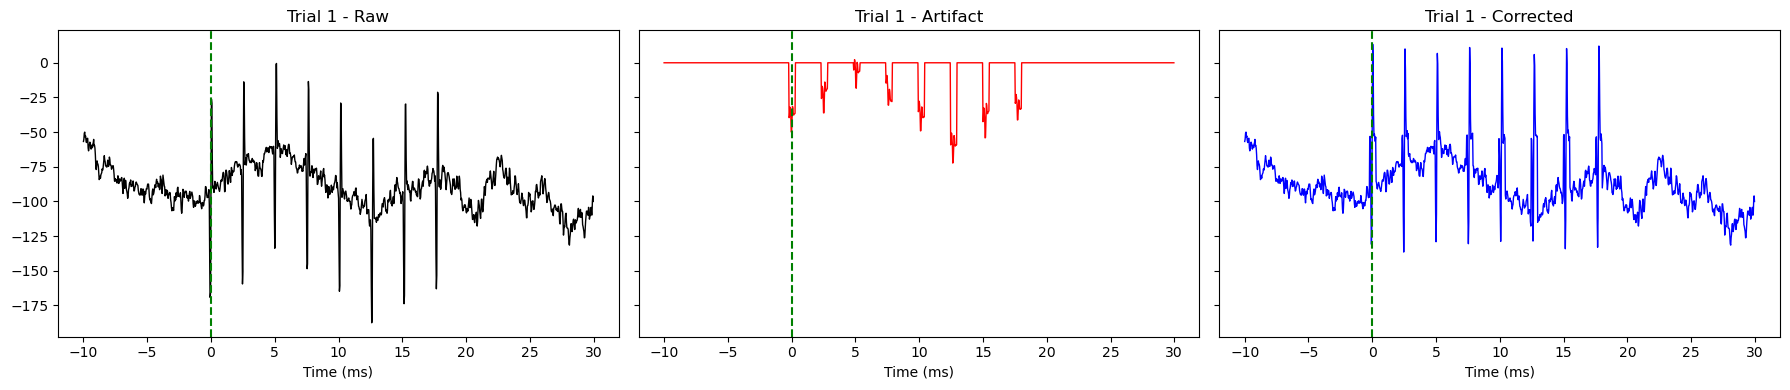

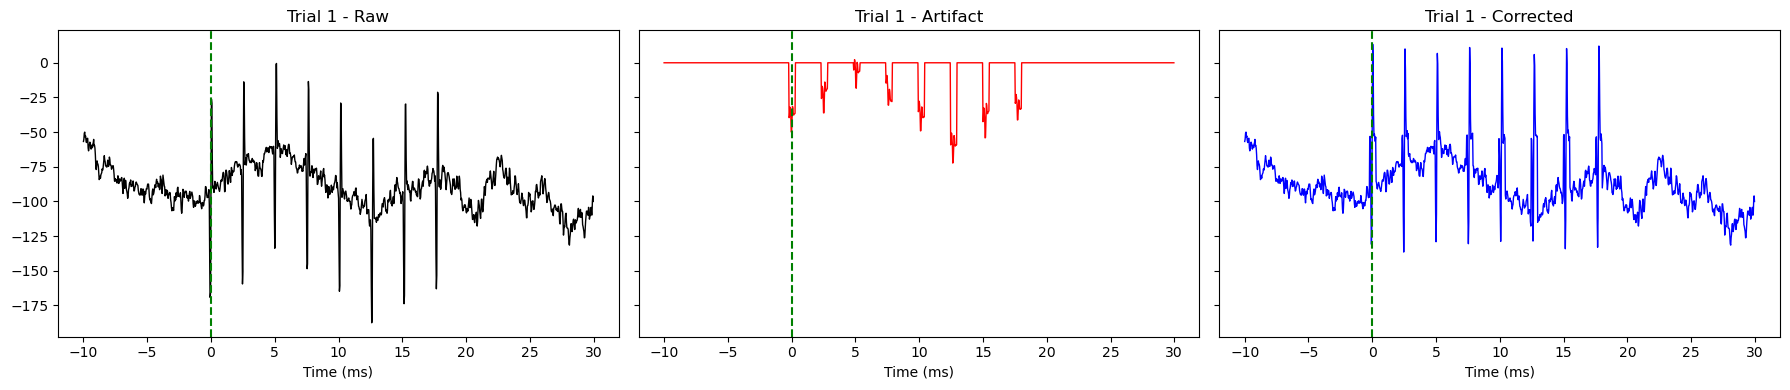

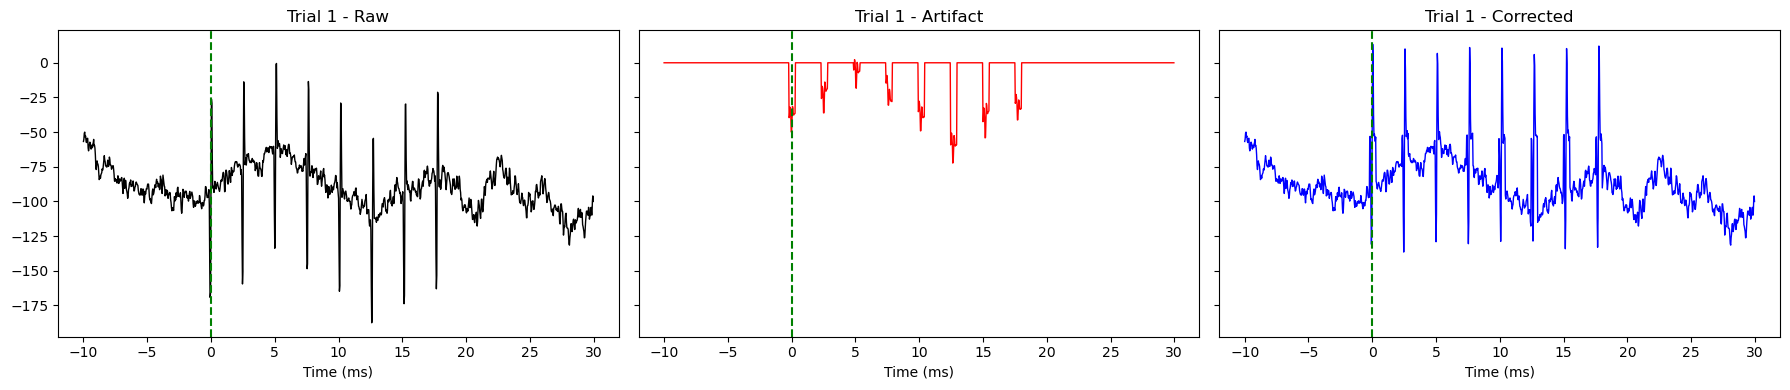

In [70]:
# Example: plot trial 0
fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharex=True, sharey=True)
trial_idx = 0
axes[0].plot(time_axis, full_raw_array[trial_idx], color='k', lw=1)
axes[0].set_title(f'Trial {trial_idx+1} - Raw')
axes[1].plot(time_axis, full_artifact_array[trial_idx], color='r', lw=1)
axes[1].set_title(f'Trial {trial_idx+1} - Artifact')
axes[2].plot(time_axis, full_corr_array[trial_idx], color='b', lw=1)
axes[2].set_title(f'Trial {trial_idx+1} - Corrected')
for ax in axes:
    ax.axvline(0, color='g', ls='--', label='Stim onset')
    ax.set_xlabel('Time (ms)')
plt.tight_layout(); plt.show()


## Zoomed Single-Pulse View

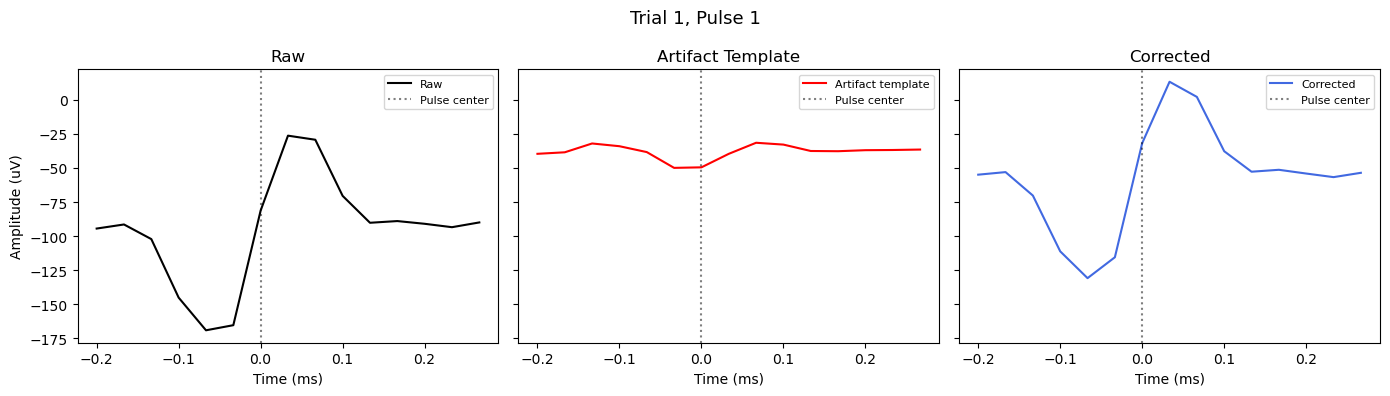

In [71]:
# Zoomed single-pulse view - raw, artifact template, corrected
trial_idx = 0   # which trial to show
pulse_in_trial = 0  # which pulse within that trial (0 = first pulse)

trial_pulses = [(idx, ps, pe) for idx, (t, ps, pe) in enumerate(micro_map) if t == trial_idx]

if not trial_pulses:
    print(f"No pulses found for trial {trial_idx}")
else:
    glob_idx, p_start, p_end = trial_pulses[pulse_in_trial]

    raw_snippet  = micro_signal_array[glob_idx, :, 0]
    corr_snippet = micro_corrected[glob_idx, :, 0]
    art_snippet  = raw_snippet - corr_snippet

    fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
    axes[0].plot(micro_time_axis, raw_snippet,  color='k',    lw=1.5, label='Raw')
    axes[1].plot(micro_time_axis, art_snippet,  color='r',    lw=1.5, label='Artifact template')
    axes[2].plot(micro_time_axis, corr_snippet, color='royalblue', lw=1.5, label='Corrected')

    for ax, title in zip(axes, ['Raw', 'Artifact Template', 'Corrected']):
        ax.axvline(0, color='k', ls=':', alpha=0.5, label='Pulse center')
        ax.set_xlabel('Time (ms)')
        ax.set_title(title)
        ax.legend(fontsize=8)

    axes[0].set_ylabel('Amplitude (uV)')
    fig.suptitle(f'Trial {trial_idx+1}, Pulse {pulse_in_trial+1}', fontsize=13)
    plt.tight_layout()
    plt.show()


## Linear Interpolation Blanking

Artifact shift vs prediction: mean=-0.033 ms, std=0.000 ms, range=[-0.033, -0.033] ms


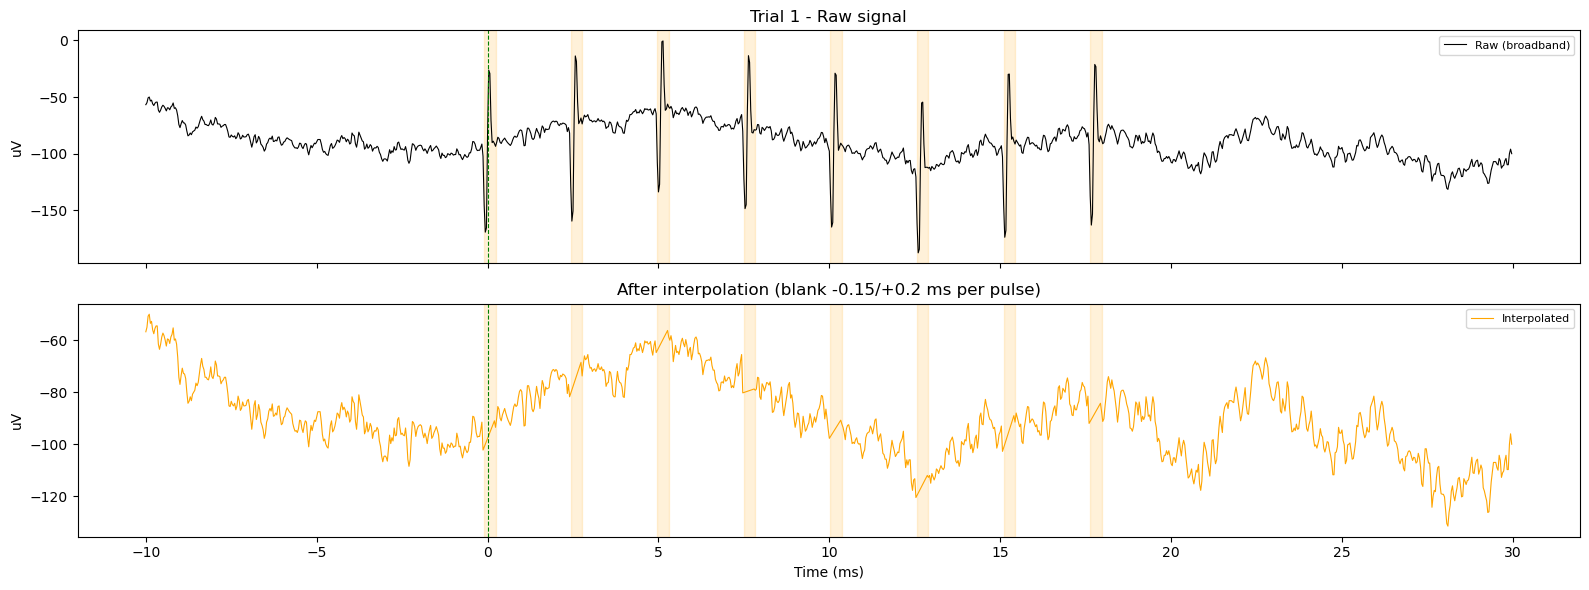

In [73]:
# Linear interpolation blanking across each stimulus pulse
BLANK_PRE_MS  = 0.15   # ms before detected peak to start interpolation
BLANK_POST_MS = 0.2   # ms after  detected peak to end   interpolation
SEARCH_MS     = 0.15  # ms search radius around predicted time to find UA peak
trial_idx     = 0

blank_pre_samp  = int(round(BLANK_PRE_MS  / 1000.0 * fs))
blank_post_samp = int(round(BLANK_POST_MS / 1000.0 * fs))
search_samp     = int(round(SEARCH_MS     / 1000.0 * fs))

raw_trace    = full_raw_array[trial_idx].copy()
interp_trace = raw_trace.copy()

trial_pulses = [(gi, ps, pe) for gi, (t, ps, pe) in enumerate(micro_map) if t == trial_idx]

shifts_ms = []

for glob_idx, p_start, p_end in trial_pulses:
    predicted_center = (p_start + p_end) // 2

    s0 = max(0, predicted_center - search_samp)
    s1 = min(len(raw_trace), predicted_center + search_samp + 1)

    chunk_diff = np.abs(np.diff(raw_trace[s0:s1], prepend=raw_trace[s0]))
    detected_center = s0 + np.argmax(chunk_diff)

    shifts_ms.append((detected_center - predicted_center) / fs * 1000.0)

    b0 = max(0, detected_center - blank_pre_samp)
    b1 = min(len(interp_trace) - 1, detected_center + blank_post_samp)

    v0 = interp_trace[b0]
    v1 = interp_trace[b1]
    n  = b1 - b0
    if n > 0:
        interp_trace[b0:b1+1] = np.linspace(v0, v1, n + 1)

shifts_ms = np.array(shifts_ms)
print(f"Artifact shift vs prediction: mean={np.mean(shifts_ms):.3f} ms, "
      f"std={np.std(shifts_ms):.3f} ms, range=[{np.min(shifts_ms):.3f}, {np.max(shifts_ms):.3f}] ms")

fig, axes = plt.subplots(2, 1, figsize=(16, 6), sharex=True)

axes[0].plot(time_axis, raw_trace,    color='k',         lw=0.8, label='Raw (broadband)')
axes[0].set_title(f'Trial {trial_idx+1} - Raw signal')
axes[0].set_ylabel('uV')

axes[1].plot(time_axis, interp_trace, color='orange',    lw=0.8, label='Interpolated')
axes[1].set_title(f'After interpolation (blank -{BLANK_PRE_MS}/+{BLANK_POST_MS} ms per pulse)')
axes[1].set_ylabel('uV')
axes[1].set_xlabel('Time (ms)')

for ax in axes:
    ax.axvline(0, color='g', ls='--', lw=0.8)
    for glob_idx, p_start, p_end in trial_pulses:
        pc = (p_start + p_end) // 2
        t0 = time_axis[max(0, pc - blank_pre_samp)]
        t1 = time_axis[min(len(time_axis)-1, pc + blank_post_samp)]
        ax.axvspan(t0, t1, color='orange', alpha=0.15)
    ax.legend(fontsize=8, loc='upper right')

plt.tight_layout()
plt.show()


## High-Pass Filter on Interpolated Data

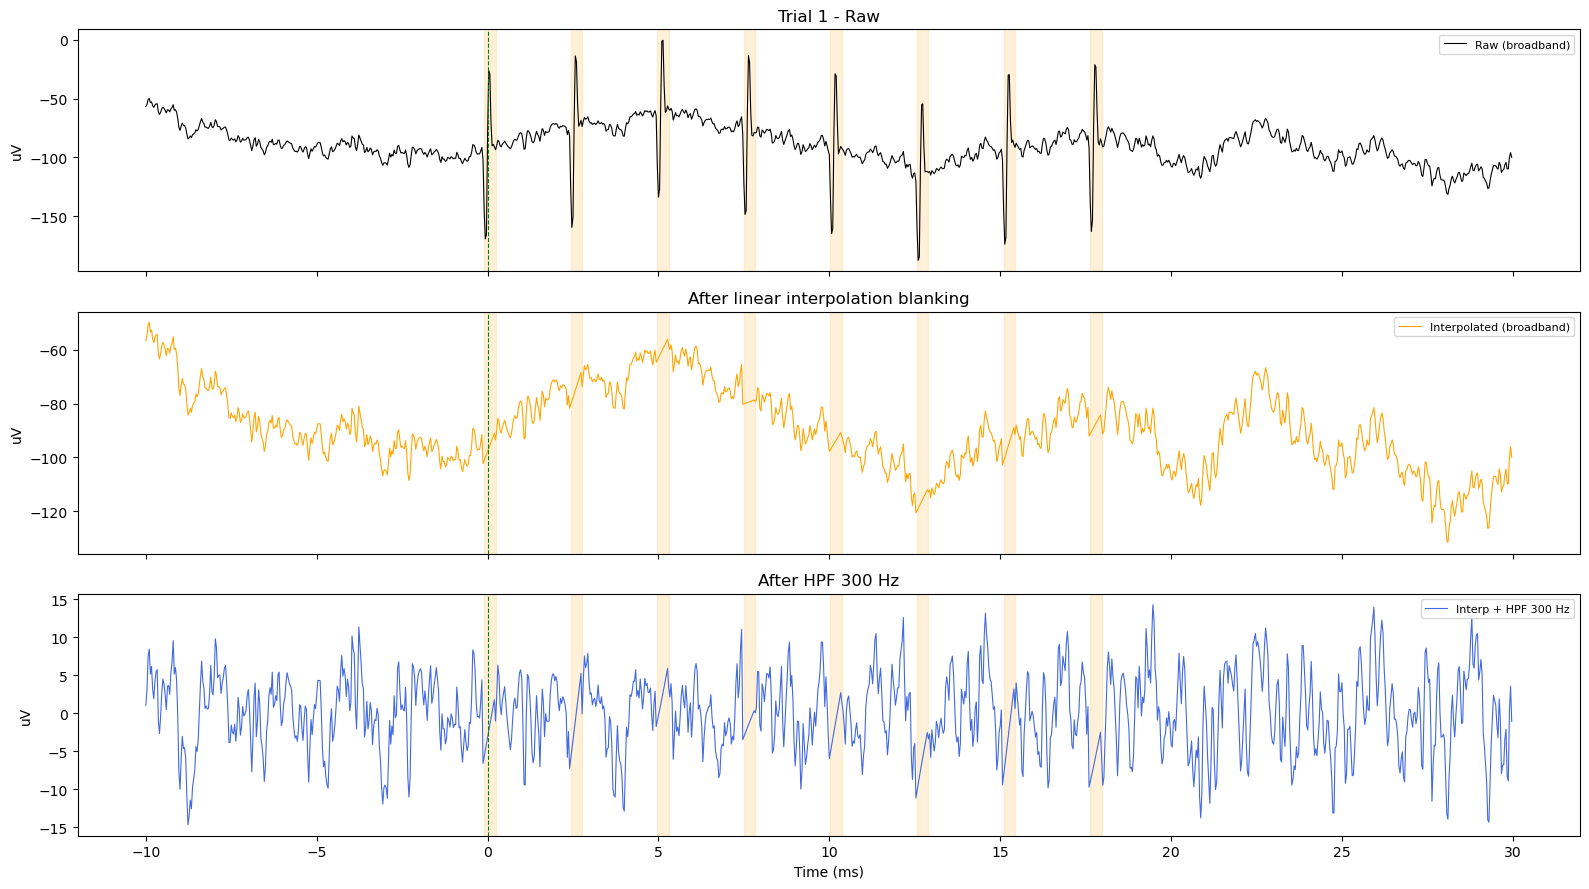

In [74]:
from scipy.signal import butter, filtfilt

HPF_CUTOFF_HZ = 300.0

b, a = butter(4, HPF_CUTOFF_HZ / (fs / 2.0), btype='high')
interp_hpf = filtfilt(b, a, interp_trace)

fig, axes = plt.subplots(3, 1, figsize=(16, 9), sharex=True)

axes[0].plot(time_axis, raw_trace, color='k', lw=0.8, label='Raw (broadband)')
axes[0].set_title(f'Trial {trial_idx+1} - Raw')
axes[0].set_ylabel('uV')

axes[1].plot(time_axis, interp_trace, color='orange', lw=0.8, label='Interpolated (broadband)')
axes[1].set_title('After linear interpolation blanking')
axes[1].set_ylabel('uV')

axes[2].plot(time_axis, interp_hpf, color='royalblue', lw=0.8, label=f'Interp + HPF {HPF_CUTOFF_HZ:.0f} Hz')
axes[2].set_title(f'After HPF {HPF_CUTOFF_HZ:.0f} Hz')
axes[2].set_ylabel('uV')
axes[2].set_xlabel('Time (ms)')

for ax in axes:
    ax.axvline(0, color='g', ls='--', lw=0.8)
    for glob_idx, p_start, p_end in trial_pulses:
        pc = (p_start + p_end) // 2
        t0 = time_axis[max(0, pc - blank_pre_samp)]
        t1 = time_axis[min(len(time_axis)-1, pc + blank_post_samp)]
        ax.axvspan(t0, t1, color='orange', alpha=0.15)
    ax.legend(fontsize=8, loc='upper right')

plt.tight_layout()
plt.show()


## Zoomed Single-Pulse View

In [ ]:
# Zoomed single-pulse view - raw, artifact template, corrected
trial_idx = 0   # which trial to show
pulse_in_trial = 0  # which pulse within that trial (0 = first pulse)

trial_pulses = [(idx, ps, pe) for idx, (t, ps, pe) in enumerate(micro_map) if t == trial_idx]

if not trial_pulses:
    print(f"No pulses found for trial {trial_idx}")
else:
    glob_idx, p_start, p_end = trial_pulses[pulse_in_trial]

    raw_snippet  = micro_signal_array[glob_idx, :, 0]
    corr_snippet = micro_corrected[glob_idx, :, 0]
    art_snippet  = raw_snippet - corr_snippet

    fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
    axes[0].plot(micro_time_axis, raw_snippet,  color='k',    lw=1.5, label='Raw')
    axes[1].plot(micro_time_axis, art_snippet,  color='r',    lw=1.5, label='Artifact template')
    axes[2].plot(micro_time_axis, corr_snippet, color='royalblue', lw=1.5, label='Corrected')

    for ax, title in zip(axes, ['Raw', 'Artifact Template', 'Corrected']):
        ax.axvline(0, color='k', ls=':', alpha=0.5, label='Pulse center')
        ax.set_xlabel('Time (ms)')
        ax.set_title(title)
        ax.legend(fontsize=8)

    axes[0].set_ylabel('Amplitude (uV)')
    fig.suptitle(f'Trial {trial_idx+1}, Pulse {pulse_in_trial+1}', fontsize=13)
    plt.tight_layout()
    plt.show()


## Linear Interpolation Blanking

In [ ]:
# Linear interpolation blanking across each stimulus pulse
BLANK_PRE_MS  = 0.1   # ms before detected peak to start interpolation
BLANK_POST_MS = 0.2   # ms after  detected peak to end   interpolation
SEARCH_MS     = 0.15  # ms search radius around predicted time to find UA peak
trial_idx     = 0

blank_pre_samp  = int(round(BLANK_PRE_MS  / 1000.0 * fs))
blank_post_samp = int(round(BLANK_POST_MS / 1000.0 * fs))
search_samp     = int(round(SEARCH_MS     / 1000.0 * fs))

raw_trace    = full_raw_array[trial_idx].copy()
interp_trace = raw_trace.copy()

trial_pulses = [(gi, ps, pe) for gi, (t, ps, pe) in enumerate(micro_map) if t == trial_idx]

shifts_ms = []

for glob_idx, p_start, p_end in trial_pulses:
    predicted_center = (p_start + p_end) // 2

    s0 = max(0, predicted_center - search_samp)
    s1 = min(len(raw_trace), predicted_center + search_samp + 1)

    chunk_diff = np.abs(np.diff(raw_trace[s0:s1], prepend=raw_trace[s0]))
    detected_center = s0 + np.argmax(chunk_diff)

    shifts_ms.append((detected_center - predicted_center) / fs * 1000.0)

    b0 = max(0, detected_center - blank_pre_samp)
    b1 = min(len(interp_trace) - 1, detected_center + blank_post_samp)

    v0 = interp_trace[b0]
    v1 = interp_trace[b1]
    n  = b1 - b0
    if n > 0:
        interp_trace[b0:b1+1] = np.linspace(v0, v1, n + 1)

shifts_ms = np.array(shifts_ms)
print(f"Artifact shift vs prediction: mean={np.mean(shifts_ms):.3f} ms, "
      f"std={np.std(shifts_ms):.3f} ms, range=[{np.min(shifts_ms):.3f}, {np.max(shifts_ms):.3f}] ms")

fig, axes = plt.subplots(2, 1, figsize=(16, 6), sharex=True)

axes[0].plot(time_axis, raw_trace,    color='k',         lw=0.8, label='Raw (broadband)')
axes[0].set_title(f'Trial {trial_idx+1} - Raw signal')
axes[0].set_ylabel('uV')

axes[1].plot(time_axis, interp_trace, color='orange',    lw=0.8, label='Interpolated')
axes[1].set_title(f'After interpolation (blank -{BLANK_PRE_MS}/+{BLANK_POST_MS} ms per pulse)')
axes[1].set_ylabel('uV')
axes[1].set_xlabel('Time (ms)')

for ax in axes:
    ax.axvline(0, color='g', ls='--', lw=0.8)
    for glob_idx, p_start, p_end in trial_pulses:
        pc = (p_start + p_end) // 2
        t0 = time_axis[max(0, pc - blank_pre_samp)]
        t1 = time_axis[min(len(time_axis)-1, pc + blank_post_samp)]
        ax.axvspan(t0, t1, color='orange', alpha=0.15)
    ax.legend(fontsize=8, loc='upper right')

plt.tight_layout()
plt.show()


## High-Pass Filter on Interpolated Data

In [ ]:
from scipy.signal import butter, filtfilt

HPF_CUTOFF_HZ = 300.0

b, a = butter(4, HPF_CUTOFF_HZ / (fs / 2.0), btype='high')
interp_hpf = filtfilt(b, a, interp_trace)

fig, axes = plt.subplots(3, 1, figsize=(16, 9), sharex=True)

axes[0].plot(time_axis, raw_trace, color='k', lw=0.8, label='Raw (broadband)')
axes[0].set_title(f'Trial {trial_idx+1} - Raw')
axes[0].set_ylabel('uV')

axes[1].plot(time_axis, interp_trace, color='orange', lw=0.8, label='Interpolated (broadband)')
axes[1].set_title('After linear interpolation blanking')
axes[1].set_ylabel('uV')

axes[2].plot(time_axis, interp_hpf, color='royalblue', lw=0.8, label=f'Interp + HPF {HPF_CUTOFF_HZ:.0f} Hz')
axes[2].set_title(f'After HPF {HPF_CUTOFF_HZ:.0f} Hz')
axes[2].set_ylabel('uV')
axes[2].set_xlabel('Time (ms)')

for ax in axes:
    ax.axvline(0, color='g', ls='--', lw=0.8)
    for glob_idx, p_start, p_end in trial_pulses:
        pc = (p_start + p_end) // 2
        t0 = time_axis[max(0, pc - blank_pre_samp)]
        t1 = time_axis[min(len(time_axis)-1, pc + blank_post_samp)]
        ax.axvspan(t0, t1, color='orange', alpha=0.15)
    ax.legend(fontsize=8, loc='upper right')

plt.tight_layout()
plt.show()
